# Titanic Survival Prediction
### A Classification Project - Predicting Passenger Survival using Machine Learning

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('Titanic-Dataset.csv')

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1]:
import os

os.makedirs('images', exist_ok=True)

In [14]:
df.info()

print("\n" + "="*50 + "\n")

print("Missing values per column:")
print(df.isnull().sum())

print("\n" + "="*50 + "\n")

print("Percentage missing:")
print((df.isnull().sum() / len(df)) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embark

In [17]:
#Survived vs. Not-Survived
print(df['Survived'].value_counts())

print("\n" + "="*50 +"\n")

print(df['Survived'].value_counts(normalize=True)*100)

Survived
0    549
1    342
Name: count, dtype: int64


Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [22]:
#Survival rate by Sex
print("Survival Rate by Sex:")
print(df.groupby('Sex')['Survived'].mean() * 100)

print("\n" + "="*50 + "\n")

#Survival rate by Passenger Class
print("Survival Rate by Pclass:")
print(df.groupby('Pclass')['Survived'].mean() * 100)

print("\n" + "="*50 + "\n")

#Survival rate by Sex and Pclass together
print("Survival Rate by Sex and Pclass combined:")
print(df.groupby(['Sex', 'Pclass'])['Survived'].mean() * 100)

Survival Rate by Sex:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


Survival Rate by Pclass:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


Survival Rate by Sex and Pclass combined:
Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64


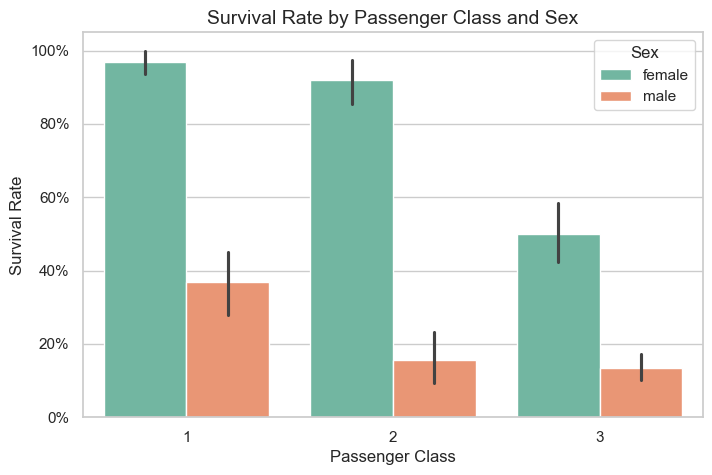

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', palette='Set2')

plt.title('Survival Rate by Passenger Class and Sex', fontsize=14)
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.legend(title='Sex')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.savefig('images/survival_by_class_sex.png', dpi=300, bbox_inches='tight')

plt.show()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


Average Age by Survival:
Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64




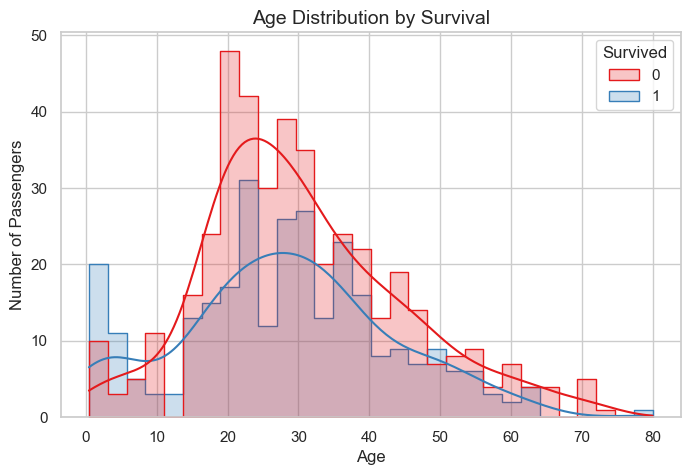

In [7]:
print(df['Age'].describe())

print("\n" + "="*50 + "\n")

#Age of survivors vs. non-survivors
print("Average Age by Survival:")
print(df.groupby('Survived')['Age'].mean())

print("\n" + "="*50 + "\n")

#Age visualization, split by survival
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, palette='Set1', element='step')
plt.title('Age Distribution by Survival', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.savefig('images/surviva_by_age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
print(df.groupby(['Pclass', 'Sex'])['Age'].median())

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


In [12]:
#To Fill empty values in the Age column 

def fill_age(row):
    if pd.isnull(row['Age']):
        if row['Pclass'] == 1 and row['Sex'] == 'female':
            return 35.0
        elif row['Pclass'] == 1 and row['Sex'] == 'male':
            return 40.0
        elif row['Pclass'] == 2 and row['Sex'] == 'female':
            return 28.0
        elif row['Pclass'] == 2 and row['Sex'] == 'male':
            return 30.0
        elif row['Pclass'] == 3 and row['Sex'] == 'female':
            return 21.5
        else: 
            return 25.0
    else:
        return row['Age']
df['Age'] = df.apply(fill_age, axis=1)

print("Missing Age values after fixing:", df['Age'].isnull().sum())

Missing Age values after fixing: 0


In [13]:
#To fill the 2 missing values in the Embarked column
print(df['Embarked'].value_counts())

print("\n" + "="*50 + "\n")

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Missing Embarked values after fixing:", df['Embarked'].isnull().sum())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


Missing Embarked values after fixing: 0


In [14]:
#To fix missing values in the Cabin column (We create a new column "Deck")
df['Deck'] = df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'Unknown')

print(df['Deck'].value_counts())

print("\n" + "="*50 + "\n")

print(df.groupby('Deck')['Survived'].mean() * 100)

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


Deck
A          46.666667
B          74.468085
C          59.322034
D          75.757576
E          75.000000
F          61.538462
G          50.000000
T           0.000000
Unknown    29.985444
Name: Survived, dtype: float64


In [15]:
#Creating the Family Size column made up of siblings/spouses (SibSp) 
# and Parents/Children (Parch)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print(df.groupby('FamilySize')['Survived'].mean() * 100)

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64


In [16]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(df.groupby('IsAlone')['Survived'].mean() * 100)

IsAlone
0    50.564972
1    30.353818
Name: Survived, dtype: float64


In [17]:
#Extracting title from name

df['Title'] =df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print(df['Title'].value_counts())

print("\n" + "="*50 + "\n")

print(df.groupby('Title')['Survived'].mean() * 100)

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


Title
Capt          0.000000
Col          50.000000
Countess    100.000000
Don           0.000000
Dr           42.857143
Jonkheer      0.000000
Lady        100.000000
Major        50.000000
Master       57.500000
Miss         69.780220
Mlle        100.000000
Mme         100.000000
Mr           15.667311
Mrs          79.200000
Ms          100.000000
Rev           0.000000
Sir         100.000000
Name: Survived, dtype: float64


In [18]:
#Cleaning the title column and creating a new column for rare titles

df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Don', 'Lady', 'Sir', 'Capt', 'Countess', 'Jonkheer']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

print(df['Title'].value_counts())
print("\n" + "="*50 + "\n")
print(df.groupby('Title')['Survived'].mean() * 100)

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


Title
Master    57.500000
Miss      70.270270
Mr        15.667311
Mrs       79.365079
Rare      34.782609
Name: Survived, dtype: float64


In [19]:
#Dropping columns I no longer need
df_model = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis = 1)

print(df_model.columns.tolist())
print("\nshape now:", df_model.shape)

['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Deck', 'FamilySize', 'IsAlone', 'Title']

shape now: (891, 10)


In [20]:
#Turning text into numbers (Encoding)
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female':1})

df_model = pd.get_dummies(df_model, columns=['Embarked', 'Deck', 'Title'], drop_first=True)

print(df_model.dtypes)
print("\nshape after encoding:", df_model.shape)

Survived          int64
Pclass            int64
Sex               int64
Age             float64
Fare            float64
FamilySize        int64
IsAlone           int64
Embarked_Q         bool
Embarked_S         bool
Deck_B             bool
Deck_C             bool
Deck_D             bool
Deck_E             bool
Deck_F             bool
Deck_G             bool
Deck_T             bool
Deck_Unknown       bool
Title_Miss         bool
Title_Mr           bool
Title_Mrs          bool
Title_Rare         bool
dtype: object

shape after encoding: (891, 21)


In [21]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X = df_model.drop('Survived', axis = 1)
y = df_model['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (712, 20)
Testing set size: (179, 20)


In [22]:
#Model Training - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Initialize the model
log_model = LogisticRegression(max_iter=1000)

#Train the model
log_model.fit(X_train, y_train)

#Make Predictions
log_predictions = log_model.predict(X_test)

#Evaluate Performance
print("Accuracy:", accuracy_score(y_test, log_predictions))
print("\nClassification Report:\n", classification_report(y_test, log_predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, log_predictions))

Accuracy: 0.8212290502793296

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179


Confusion Matrix:
 [[97 13]
 [19 50]]


In [23]:
#Model Training - Random Forest
from sklearn.ensemble import RandomForestClassifier

#Initialize and Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#Predict
rf_predictions = rf_model.predict(X_test)

#Evaluate
print("Accuracy:", accuracy_score(y_test, rf_predictions))
print("\nClassification Report:\n", classification_report(y_test, rf_predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_predictions))

Accuracy: 0.7877094972067039

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       110
           1       0.74      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179


Confusion Matrix:
 [[93 17]
 [21 48]]


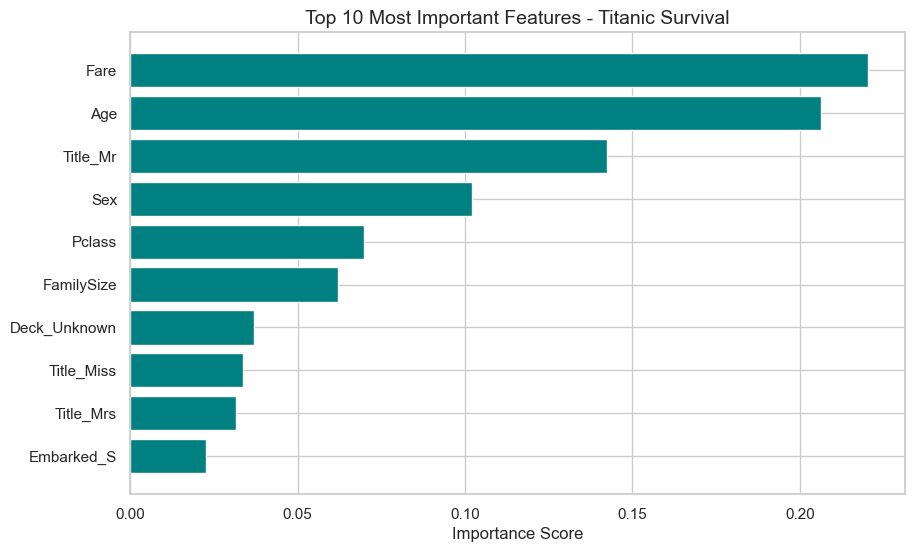

         Feature  Importance
3           Fare    0.220445
2            Age    0.206413
17      Title_Mr    0.142400
1            Sex    0.102042
0         Pclass    0.069955
4     FamilySize    0.062143
15  Deck_Unknown    0.037062
16    Title_Miss    0.033793
18     Title_Mrs    0.031748
7     Embarked_S    0.022728


<Figure size 640x480 with 0 Axes>

In [24]:
#Feature Importance (Using Random Forest)
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10], color='teal')
plt.title('Top 10 Most Important Features - Titanic Survival', fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

plt.savefig('images/feature_importance.png', dpi=300, bbox_inches='tight')

print(feature_importance_df.head(10))

# Summary
### - Built a classification model predicting Titanic passenger survival with 82% accuracy (Logistic Regression baseline).
### - Identified gender, class, and fare as the strongest survival predictors — confirming "women and children first" and wealth-based prioritization, with feature engineering (Title, Deck, FamilySize) improving on raw columns alone.
### - Notable finding: whether a cabin was recorded at all was itself predictive — passengers with known cabins survived at roughly double the rate of those without.
### - Compared Logistic Regression vs Random Forest; the simpler model outperformed the more complex one, highlighting the importance of baseline comparison over model complexity.

In [63]:
#TO PREDICT A MADE-UP PASSENGER (TEST - 1)

new_passenger = pd.DataFrame({
    'Pclass': [1],
    'Sex': [1],                #1 = female
    'Age': [28],
    'Fare': [100],
    'FamilySize': [1],
    'IsAlone': [1],
    'Embarked_Q': [False],
    'Embarked_S': [False],
    'Deck_B': [True],
    'Deck_C': [False],
    'Deck_D': [False],
    'Deck_E': [False],
    'Deck_F': [False],
    'Deck_G': [False],
    'Deck_T': [False],
    'Deck_Unknown': [False],
    'Title_Miss': [True],
    'Title_Mr': [False],
    'Title_Mrs': [False],
    'Title_Rare': [False]
})

new_passenger = new_passenger[X_train.columns]

prediction = log_model.predict(new_passenger)
probability = log_model.predict_proba(new_passenger)

print("Prediction (0 = Died, 1 = Survived):", prediction[0])
print("Probability of dying vs surviving:", probability[0])

Prediction (0 = Died, 1 = Survived): 1
Probability of dying vs surviving: [0.05345866 0.94654134]


In [64]:
#TO PREDICT A MADE-UP PASSENGER (TEST - 2)

new_passenger_2 = pd.DataFrame({
    'Pclass': [3],
    'Sex': [0],             # 0 = male
    'Age': [40],
    'Fare': [7],             
    'FamilySize': [1],
    'IsAlone': [1],
    'Embarked_Q': [False],
    'Embarked_S': [True],    
    'Deck_B': [False],
    'Deck_C': [False],
    'Deck_D': [False],
    'Deck_E': [False],
    'Deck_F': [False],
    'Deck_G': [False],
    'Deck_T': [False],
    'Deck_Unknown': [True],
    'Title_Miss': [False],
    'Title_Mr': [True],
    'Title_Mrs': [False],
    'Title_Rare': [False]
})

new_passenger_2 = new_passenger_2[X_train.columns]

prediction_2 = log_model.predict(new_passenger_2)
probability_2 = log_model.predict_proba(new_passenger_2)

print("Prediction (0 = Died, 1 = Survived):", prediction_2[0])
print("Probability of dying vs surviving:", probability_2[0])

Prediction (0 = Died, 1 = Survived): 0
Probability of dying vs surviving: [0.95031401 0.04968599]
